# Notebook 6 — Predictive Modeling: Late-Delivery & Negative-Review Risk Scoring

**Project:** E-Commerce Retail & Fulfillment Analytics — an Amazon Retail / Operations analog
built on the Olist Brazilian e-commerce dataset (Sep-2016 – Oct-2018).

## Where this fits in the project

NB3's geospatial analysis (H6) established that seller-customer distance is a structural
driver of delivery delay and lateness. NB4's hypothesis testing (F31/F32) showed that whether
an order arrives late is, by a wide margin, the single strongest driver of review score
(Cliff's delta = -0.554, "large" effect; mean review 4.29 -> 2.57, on-time vs. late). NB5's
clustering rediscovered the same signal at the customer level: a 7.9%-of-customers "At-Risk:
Late & Unhappy" segment, defined almost entirely by a 99.7% late rate and a 2.55/5 average
review.

Every one of those findings is **retrospective** — each describes orders or customers *after*
the outcome (late delivery, bad review, churn risk) is already locked in. The natural question
for a senior analyst to ask next is: how much of this is **predictable in advance**, while
there's still time to act on it?

This notebook builds **two complementary risk-scoring models** that turn NB1-5's descriptive
findings into forward-looking, deployable signals:

- **Model A — Late-Delivery Risk** (Section 1): at the **moment of purchase**, using only
  information available then (the delivery-date promise, seller-customer distance, order
  economics, category, seasonality) — what is P(this order arrives late)?
- **Model B — Negative-Review Risk** (Section 2): immediately **after delivery**, now that the
  actual delivery outcome is known — what is P(this customer leaves a 1-2 star review)?

Section 3 chains the two together into a single two-stage early-warning pipeline and shows,
empirically, that Model A's order-time score — built with zero information about reviews —
already carries a measurable signal about eventual customer satisfaction.

## Roadmap for the full project

| # | Notebook | Focus |
|---|---|---|
| 1 | `01_data_profiling_and_eda.ipynb` | Profiling, missingness, univariate/bivariate/multivariate EDA |
| 2 | `02_time_series_decomposition.ipynb` | Trend/seasonality decomposition of orders & revenue |
| 3 | `03_geospatial_analysis.ipynb` | State/city geography — demand, delivery, satisfaction, supply-vs-demand |
| 4 | `04_hypothesis_testing.ipynb` | Formal statistical tests — delivery delay vs. review score, category/region effects |
| 5 | `05_customer_segmentation.ipynb` | RFM recap + K-Means clustering, segment profiles |
| 6 | `06_predictive_modeling.ipynb` (this notebook) | Risk scoring — late delivery (order time) & negative review (post-delivery) |

## Roadmap for this notebook

1. Model A — Late-Delivery Risk: data, train/test methodology, models, coefficients, ROC/PR,
   decile lift, threshold-based business framing
2. Model B — Negative-Review Risk: same structure, post-delivery features
3. Cross-model synthesis — chaining Model A's order-time score into Model B's outcome
4. Deployment recommendations
5. Key Findings Summary

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, confusion_matrix,
)
import statsmodels.api as sm

from etl.db import get_engine

%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

engine = get_engine()

# Brazilian state -> IBGE macro-region map (reused from NB3/NB4/NB5)
BR_REGION = {
    "AC": "North", "AP": "North", "AM": "North", "PA": "North", "RO": "North", "RR": "North", "TO": "North",
    "AL": "Northeast", "BA": "Northeast", "CE": "Northeast", "MA": "Northeast", "PB": "Northeast",
    "PE": "Northeast", "PI": "Northeast", "RN": "Northeast", "SE": "Northeast",
    "DF": "Central-West", "GO": "Central-West", "MT": "Central-West", "MS": "Central-West",
    "ES": "Southeast", "MG": "Southeast", "RJ": "Southeast", "SP": "Southeast",
    "PR": "South", "RS": "South", "SC": "South",
}
REGION_ORDER = ["North", "Northeast", "Central-West", "Southeast", "South"]
REGION_COLORS = dict(zip(REGION_ORDER, sns.color_palette("deep", 5).as_hex()))

RANDOM_STATE = 42

def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in km (reused from NB3/NB4/NB5)."""
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def build_X(df, num_feats, cat_feats, ref_cols=None):
    """One-hot encode categoricals + concatenate numeric features; align test columns to train."""
    X_num = df[num_feats].fillna(0)
    X_cat = pd.get_dummies(df[cat_feats].astype(str), drop_first=True)
    X = pd.concat([X_num, X_cat], axis=1)
    if ref_cols is not None:
        X = X.reindex(columns=ref_cols, fill_value=0)
    return X

def decile_table(y_true, y_proba, n_bins=10):
    """Rank-order lift table: decile 1 = highest predicted risk."""
    d = pd.DataFrame({"y": np.asarray(y_true), "p": np.asarray(y_proba)})
    d["decile"] = n_bins - pd.qcut(d["p"].rank(method="first"), n_bins, labels=False)
    g = d.groupby("decile").agg(n=("y", "size"), n_pos=("y", "sum"), avg_predicted_prob=("p", "mean")).sort_index()
    g["actual_rate"] = g["n_pos"] / g["n"]
    g["pct_of_all_positives"] = g["n_pos"] / g["n_pos"].sum()
    g["cum_pct_positives"] = g["pct_of_all_positives"].cumsum()
    g["cum_pct_orders"] = g["n"].cumsum() / g["n"].sum()
    g["lift"] = g["actual_rate"] / d["y"].mean()
    return g

def threshold_sweep(y_true, y_proba, thresholds=np.arange(0.1, 1.0, 0.1)):
    """Precision/recall/F1 and confusion-matrix counts across a grid of decision thresholds."""
    y_true = np.asarray(y_true)
    rows = []
    for t in thresholds:
        pred = (y_proba >= t).astype(int)
        tp = int(((pred == 1) & (y_true == 1)).sum())
        fp = int(((pred == 1) & (y_true == 0)).sum())
        fn = int(((pred == 0) & (y_true == 1)).sum())
        tn = int(((pred == 0) & (y_true == 0)).sum())
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        f1 = 2 * precision * recall / (precision + recall) if precision and recall else np.nan
        pct_flagged = (tp + fp) / len(y_true)
        rows.append([round(t, 1), pct_flagged, precision, recall, f1, tp, fp, fn, tn])
    return pd.DataFrame(rows, columns=["threshold", "pct_flagged", "precision", "recall", "f1", "tp", "fp", "fn", "tn"])

print("Setup complete.")

Setup complete.


## 1. Model A — Late-Delivery Risk: Problem Framing

**The business question.** At the moment a customer places an order, the platform has already
made an implicit promise: an estimated delivery date. NB3 (H6) and NB4 (F31/F32) together
established *why* this promise matters so much — orders that miss it are dramatically more
likely to generate a 1-2 star review, and customers whose orders are chronically late form
their own unhappy segment regardless of how much they spend (NB5). None of that, by itself,
helps Operations act *before* the fact.

**What "order-time" means here.** Model A is deliberately restricted to features that are
**knowable at the instant the order is placed** — nothing that depends on what happens
afterward (no `delivery_delay_days`, no `actual_delivery_days`, no `review_score`). This is
the feature set that could realistically sit behind a real-time "at-risk order" flag in an
operations dashboard: if Model A says an order is high-risk, there is a full fulfillment cycle's
worth of time to act on it — route to a faster carrier, set a more conservative ETA at
checkout, or proactively message the customer about a likely delay.

**Target.** `is_late` = 1 if the order was delivered after `order_estimated_delivery_date`, 0
otherwise — exactly as defined in `marts.fact_orders` and used throughout NB3/NB4.

## 1.1 Data assembly & feature engineering

**Population.** Single-seller, delivered orders with a known delivery estimate and known
seller/customer coordinates:

```sql
WHERE fo.is_delivered
  AND fo.n_distinct_sellers = 1
  AND fo.is_late IS NOT NULL
  AND fo.estimated_delivery_days IS NOT NULL
  AND dc.customer_latitude IS NOT NULL
  AND ds.seller_latitude IS NOT NULL
```

This yields **94,726 of the 95,203 delivered single-seller orders (99.5%)**. Multi-seller
orders are excluded because they don't have a single well-defined seller-customer distance
(NB3/NB4's H6 geography). Item-level fields (category) come from the order's first item
(`order_item_id = 1`).

**Order-time feature set:**

| Feature | Definition | Why it's in the model |
|---|---|---|
| `estimated_delivery_days` | `estimated_delivery_date - order_purchase_date` | the platform's own "promise length" — a longer estimate gives more buffer to hit it |
| `distance_km` | haversine distance, seller <-> customer | NB3/NB4's H6 geography finding |
| `order_total_value` | total order value | economics |
| `freight_ratio` | `freight_value_total / order_total_value` | shipping-cost burden |
| `n_items` | items in the order | basket size / pick-pack complexity |
| `max_installments` | payment installments chosen | NB4 H5c: correlates with order value |
| `is_cross_region` | 1 if customer & seller are in different IBGE macro-regions | coarse geography control alongside `distance_km` |
| `primary_payment_type` | categorical | payment-method effects |
| `category_grp` | top 26 categories (>=500 orders) individually, rest grouped "other" | category-specific logistics effects |
| `purchase_month`, `purchase_dow` | derived from `order_purchase_date` | seasonality |

All ten are available the instant the order is placed — none depend on the fulfillment
outcome.

In [2]:
dfA = pd.read_sql("""
    SELECT
        fo.order_id, fo.order_purchase_date, fo.order_total_value,
        fo.freight_value_total, fo.n_items, fo.primary_payment_type,
        fo.max_installments, fo.estimated_delivery_days, fo.is_late,
        fo.customer_state, ds.seller_state,
        dc.customer_latitude, dc.customer_longitude,
        ds.seller_latitude, ds.seller_longitude,
        dp.product_category_name_english AS category
    FROM marts.fact_orders fo
    JOIN marts.dim_customer dc ON dc.customer_unique_id = fo.customer_unique_id
    JOIN marts.fact_order_items foi ON foi.order_id = fo.order_id AND foi.order_item_id = 1
    JOIN marts.dim_seller ds ON ds.seller_id = foi.seller_id
    JOIN marts.dim_product dp ON dp.product_id = foi.product_id
    WHERE fo.is_delivered
      AND fo.n_distinct_sellers = 1
      AND fo.is_late IS NOT NULL
      AND fo.estimated_delivery_days IS NOT NULL
      AND dc.customer_latitude IS NOT NULL
      AND ds.seller_latitude IS NOT NULL
    ORDER BY fo.order_id
""", engine)

dfA["order_purchase_date"] = pd.to_datetime(dfA["order_purchase_date"])
dfA["distance_km"] = haversine_km(dfA["customer_latitude"], dfA["customer_longitude"],
                                    dfA["seller_latitude"], dfA["seller_longitude"])
dfA["customer_region"] = dfA["customer_state"].map(BR_REGION)
dfA["seller_region"] = dfA["seller_state"].map(BR_REGION)
dfA["is_cross_region"] = (dfA["customer_region"] != dfA["seller_region"]).astype(int)
dfA["purchase_month"] = dfA["order_purchase_date"].dt.month
dfA["purchase_dow"] = dfA["order_purchase_date"].dt.dayofweek
dfA["freight_ratio"] = dfA["freight_value_total"] / dfA["order_total_value"]
dfA["is_late"] = dfA["is_late"].astype(int)

print(f"Rows: {len(dfA):,}")
print(f"Date range: {dfA['order_purchase_date'].min().date()} to {dfA['order_purchase_date'].max().date()}")
print(f"is_late rate: {dfA['is_late'].mean()*100:.2f}%")

dfA = dfA.dropna(subset=["category"])
top_cats = dfA["category"].value_counts()
top_cats = top_cats[top_cats >= 500].index.tolist()
print(f"Categories with >=500 orders (kept individually, rest -> 'other'): {len(top_cats)}")
dfA["category_grp"] = np.where(dfA["category"].isin(top_cats), dfA["category"], "other")

dfA.head()

Rows: 94,726
Date range: 2016-09-15 to 2018-08-29
is_late rate: 8.19%
Categories with >=500 orders (kept individually, rest -> 'other'): 26


,order_id,order_purchase_date,order_total_value,freight_value_total,n_items,primary_payment_type,max_installments,estimated_delivery_days,is_late,customer_state,seller_state,customer_latitude,customer_longitude,seller_latitude,seller_longitude,category,distance_km,customer_region,seller_region,is_cross_region,purchase_month,purchase_dow,freight_ratio,category_grp
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13,72.19,13.29,1,credit_card,2.0,15.625671,0,RJ,SP,-21.762775,-41.309633,-22.496953,-44.127492,cool_stuff,301.504681,Southeast,Southeast,0,9,2,0.184098,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26,259.83,19.93,1,credit_card,3.0,18.546458,0,SP,SP,-20.220527,-50.903424,-23.565096,-46.518565,pet_shop,585.563937,Southeast,Southeast,0,4,2,0.076704,pet_shop
2,000229ec398224ef6ca0657da4fc703e,2018-01-14,216.87,17.87,1,credit_card,5.0,21.393391,0,MG,MG,-19.870305,-44.593326,-22.262584,-46.171124,furniture_decor,312.343511,Southeast,Southeast,0,1,6,0.082400,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08,25.78,12.79,1,credit_card,2.0,11.582928,0,SP,SP,-23.089925,-46.611654,-20.553624,-47.387359,perfumery,293.168420,Southeast,Southeast,0,8,2,0.496121,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04,218.04,18.14,1,credit_card,3.0,40.418160,0,SP,PR,-23.243402,-46.827614,-22.929384,-53.135873,garden_tools,646.163463,Southeast,South,1,2,5,0.083196,garden_tools


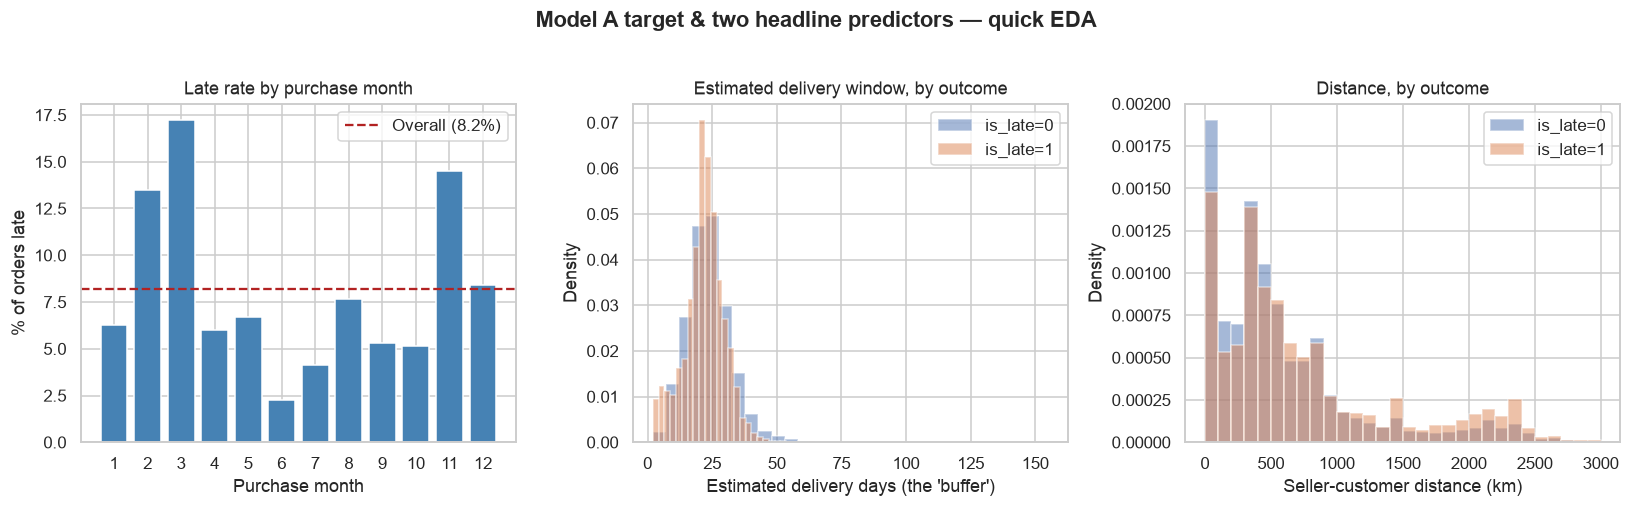

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

month_rate = dfA.groupby("purchase_month")["is_late"].mean() * 100
axes[0].bar(month_rate.index, month_rate.values, color="steelblue")
axes[0].axhline(dfA["is_late"].mean() * 100, color="firebrick", linestyle="--",
                label=f"Overall ({dfA['is_late'].mean()*100:.1f}%)")
axes[0].set_xlabel("Purchase month")
axes[0].set_ylabel("% of orders late")
axes[0].set_title("Late rate by purchase month")
axes[0].set_xticks(range(1, 13))
axes[0].legend()

for label, grp in dfA.groupby("is_late"):
    axes[1].hist(grp["estimated_delivery_days"], bins=30, alpha=0.5,
                  label=f"is_late={label}", density=True)
axes[1].set_xlabel("Estimated delivery days (the 'buffer')")
axes[1].set_ylabel("Density")
axes[1].set_title("Estimated delivery window, by outcome")
axes[1].legend()

for label, grp in dfA.groupby("is_late"):
    axes[2].hist(grp["distance_km"], bins=30, alpha=0.5,
                  label=f"is_late={label}", density=True, range=(0, 3000))
axes[2].set_xlabel("Seller-customer distance (km)")
axes[2].set_ylabel("Density")
axes[2].set_title("Distance, by outcome")
axes[2].legend()

plt.suptitle("Model A target & two headline predictors — quick EDA", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 1.2 Train/test split methodology — a worked example of why this choice matters

**A natural first instinct for "predict a future order outcome" is a temporal split** — train
on earlier orders, test on later ones, mirroring how the model would actually be deployed. We
tried exactly that first: an 80/20 split at the 80th percentile of `order_purchase_date`.

**It failed badly.** The Random Forest scored **AUC = 0.481 — worse than random guessing** on
the temporal holdout. Inspecting feature importances on that run showed the model leaned
heavily on `purchase_month` dummies — exactly the seasonal effect the EDA above hints at. The
temporal split's test period covers a different, narrower slice of the calendar than its train
period, so the seasonal dummies the model learned to rely on **don't transfer**: a model that
learned "March is risky" from one year's worth of training months is being asked to extrapolate
to months it barely saw in training, under a shifted distribution.

**Why a random split is the right call here — and how this differs from NB2.** NB2's
forecasting task ("what will November 2018 revenue be?") is *inherently* temporal — the
question only makes sense with a chronological holdout. Model A's task is different in kind:
it's a **cross-sectional risk-scoring** question — "given the attributes of *this* order
(placed whenever), how risky is it?" — a model that would be retrained periodically in
production on a rolling window. For evaluating that kind of model, a **stratified random 80/20
split** (`stratify=is_late`, `random_state=42`) is the methodologically correct choice: it
measures the model's ability to discriminate risky from safe orders *given comparable inputs*,
without penalizing it for a train/test calendar mismatch that a production retraining cadence
would never create. Under this split, the same Random Forest scores **AUC = 0.742** (Section
1.4).

**Reproducibility note.** `pd.read_sql` without an explicit `ORDER BY` returns rows in a
Postgres-internal order that is not guaranteed to be stable; combined with
`train_test_split`'s shuffle, that produced slightly different AUCs (0.7149 vs. 0.7293) across
identical reruns of this exact code during development. Every query in this notebook includes
an explicit `ORDER BY <primary key>` so results are exactly reproducible.

In [4]:
trainA, testA = train_test_split(dfA, test_size=0.2, random_state=RANDOM_STATE, stratify=dfA["is_late"])
print(f"Train: {len(trainA):,} ({trainA['is_late'].mean()*100:.2f}% late)")
print(f"Test:  {len(testA):,} ({testA['is_late'].mean()*100:.2f}% late)")

num_featsA = ["estimated_delivery_days", "distance_km", "order_total_value", "freight_ratio",
              "n_items", "max_installments", "is_cross_region"]
cat_featsA = ["primary_payment_type", "category_grp", "purchase_month", "purchase_dow"]

X_trainA = build_X(trainA, num_featsA, cat_featsA)
X_testA = build_X(testA, num_featsA, cat_featsA, ref_cols=X_trainA.columns)
y_trainA = trainA["is_late"].values
y_testA = testA["is_late"].values
print(f"\nFeature matrix shape: {X_trainA.shape}")

scalerA = StandardScaler()
X_trainA_scaled = X_trainA.copy()
X_trainA_scaled[num_featsA] = scalerA.fit_transform(X_trainA[num_featsA])
X_testA_scaled = X_testA.copy()
X_testA_scaled[num_featsA] = scalerA.transform(X_testA[num_featsA])

Train: 75,780 (8.19% late)
Test:  18,946 (8.19% late)

Feature matrix shape: (75780, 53)


## 1.3 Logistic Regression baseline & Random Forest benchmark

Two models, same train/test split and feature matrix:

- **Logistic Regression** (`class_weight="balanced"`, since only 8.19% of orders are late) —
  the interpretable baseline. Its coefficients are examined in detail in Section 1.4.
- **Random Forest** (200 trees, `max_depth=8`, `class_weight="balanced"`) — a non-linear
  benchmark that can capture interactions Logistic Regression cannot, and whose
  `feature_importances_` give a model-agnostic ranking of predictive power.

In [5]:
logregA = LogisticRegression(max_iter=1000, class_weight="balanced")
logregA.fit(X_trainA_scaled, y_trainA)
proba_logregA = logregA.predict_proba(X_testA_scaled)[:, 1]

rfA = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE,
                               class_weight="balanced", n_jobs=-1)
rfA.fit(X_trainA_scaled, y_trainA)
proba_rfA = rfA.predict_proba(X_testA_scaled)[:, 1]

results_A = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "AUC": [roc_auc_score(y_testA, proba_logregA), roc_auc_score(y_testA, proba_rfA)],
    "PR-AUC": [average_precision_score(y_testA, proba_logregA), average_precision_score(y_testA, proba_rfA)],
})
results_A["PR-AUC / base rate"] = results_A["PR-AUC"] / y_testA.mean()
results_A.round(4)

,model,AUC,PR-AUC,PR-AUC / base rate
0,Logistic Regression,0.7292,0.1850,2.2583
1,Random Forest,0.7422,0.2153,2.6285


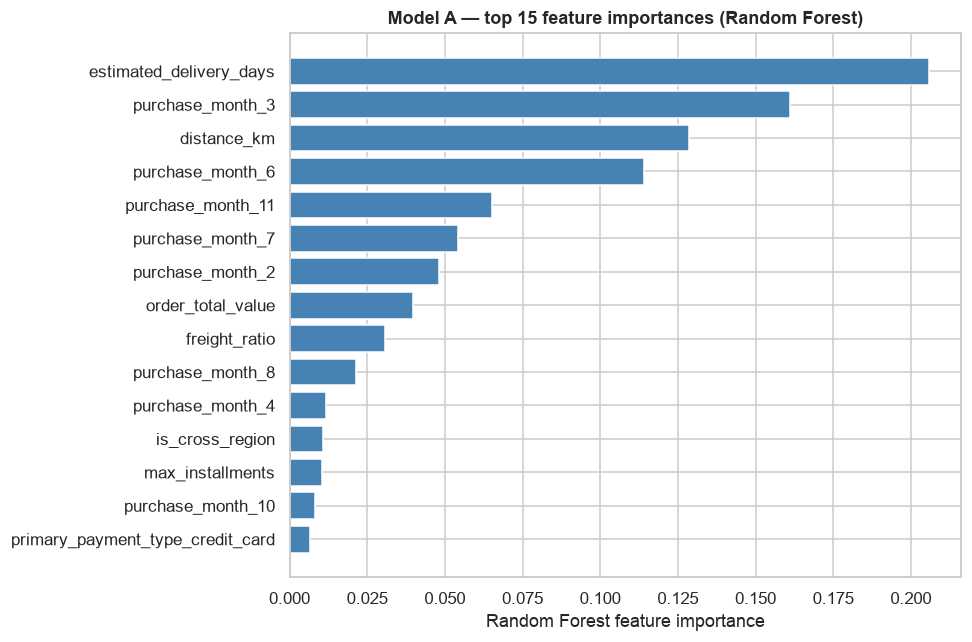

In [6]:
fiA = pd.Series(rfA.feature_importances_, index=X_trainA_scaled.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fiA.index[::-1], fiA.values[::-1], color="steelblue")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Model A — top 15 feature importances (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #44 — Both models comfortably beat the 8.19% base rate, and the two strongest
predictors are exactly NB3/NB4's headline geography and SLA findings.** Logistic Regression
reaches **AUC=0.7292 / PR-AUC=0.1850** and Random Forest reaches **AUC=0.7422 / PR-AUC=0.2153**
— a PR-AUC of ~0.215 against an 8.19% base rate means the precision-recall tradeoff is, on
average, **~2.6x better than randomly ordering orders**. Random Forest's top two importances
are `estimated_delivery_days` (0.206) — the platform's own promised delivery window — and
`distance_km` (0.129) — seller-customer geography, NB3/NB4's H6 finding. In the statsmodels
coefficients (Section 1.4) these correspond to **-0.716** for `estimated_delivery_days` (a
longer promise -> lower late risk, the "buffer effect") and **+0.541** for `distance_km` (more
distance -> higher late risk), both significant at p<0.001 and both the largest-magnitude
continuous-feature coefficients in the model. **Two notebooks' worth of descriptive geography
and SLA findings turn out to be the two strongest levers in a predictive model trained from
scratch on order-time data alone** — strong validation that NB3/NB4 identified structural
drivers, not incidental correlations.

## 1.4 Coefficient interpretation (statsmodels Logit)

The same standardized feature matrix is fit with `sm.Logit` for full inferential output —
standard errors, z-statistics, p-values and 95% CIs. **All numeric features, including the 0/1
indicator `is_cross_region`, were standardized (mean 0, SD 1) before fitting**, so coefficient
*magnitudes* are directly comparable to each other as standardized effect sizes, and
`exp(coefficient)` gives an **odds ratio per one-standard-deviation increase** for continuous
features.

In [7]:
Xc_A = sm.add_constant(X_trainA_scaled.astype(float))
logit_modelA = sm.Logit(y_trainA, Xc_A)
resA = logit_modelA.fit(disp=0, maxiter=100)

coefsA = resA.summary2().tables[1].copy()
coefsA["odds_ratio"] = np.exp(coefsA["Coef."])
coefsA.round(4)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio
const,-2.2161,0.0924,-23.9750,0.0000,-2.3972,-2.0349,0.1090
estimated_delivery_days,-0.7157,0.0232,-30.8355,0.0000,-0.7612,-0.6702,0.4889
distance_km,0.5412,0.0187,28.9026,0.0000,0.5045,0.5779,1.7181
order_total_value,0.0723,0.0133,5.4224,0.0000,0.0462,0.0984,1.0750
freight_ratio,0.0407,0.0166,2.4446,0.0145,0.0081,0.0733,1.0415
n_items,-0.0560,0.0155,-3.6055,0.0003,-0.0864,-0.0255,0.9456
max_installments,0.0605,0.0158,3.8226,0.0001,0.0295,0.0915,1.0623
is_cross_region,-0.0204,0.0199,-1.0242,0.3057,-0.0595,0.0186,0.9798
primary_payment_type_credit_card,-0.2319,0.0366,-6.3386,0.0000,-0.3036,-0.1602,0.7931
primary_payment_type_debit_card,-0.0086,0.1125,-0.0767,0.9389,-0.2291,0.2119,0.9914


In [8]:
headline_featsA = ["estimated_delivery_days", "distance_km", "order_total_value", "freight_ratio",
                    "n_items", "max_installments", "is_cross_region"]
headlineA = coefsA.loc[headline_featsA, ["Coef.", "P>|z|", "odds_ratio"]]
headlineA.columns = ["coef (per SD)", "p-value", "odds ratio (per SD)"]
headlineA.round(4)

,coef (per SD),p-value,odds ratio (per SD)
estimated_delivery_days,-0.7157,0.0000,0.4889
distance_km,0.5412,0.0000,1.7181
order_total_value,0.0723,0.0000,1.0750
freight_ratio,0.0407,0.0145,1.0415
n_items,-0.0560,0.0003,0.9456
max_installments,0.0605,0.0001,1.0623
is_cross_region,-0.0204,0.3057,0.9798


**Reading the headline continuous-feature effects:**

| Feature | Coef (per SD) | Odds ratio (per SD) | Interpretation |
|---|---|---|---|
| `estimated_delivery_days` | -0.716 | 0.49x | a 1-SD-longer promised window is associated with **51% lower odds** of being late — the "buffer effect" |
| `distance_km` | +0.541 | 1.72x | a 1-SD-greater seller-customer distance is associated with **72% higher odds** of being late |
| `order_total_value` | +0.072 | 1.07x | small but significant — higher-value orders run marginally higher late risk |
| `freight_ratio` | +0.041 | 1.04x | small, and only marginally significant (p=0.014) |
| `n_items` | -0.056 | 0.95x | slightly *protective* — larger baskets are marginally less likely to be late |
| `max_installments` | +0.060 | 1.06x | small, consistent with higher-value orders (NB4 H5c) |
| `is_cross_region` | -0.020 | 0.98x | **not significant** (p=0.31) once `distance_km` is in the model — distance, not the coarser region boundary, is what matters |

Two features the platform controls directly — the delivery estimate and (indirectly, via
seller network design) the seller-customer distance — dominate every order-economics variable
combined.

## 1.4.1 Seasonal & category effects

The remaining ~46 coefficients are `primary_payment_type`, `category_grp`, `purchase_month`
and `purchase_dow` dummies (all relative to a baseline level — boleto payment, the `other`
category group, January, and Monday respectively). The full table above contains every
coefficient; the discussion below focuses on the patterns that matter.

**FINDING #45 — Purchase month is the largest *categorical* effect in the model, with a
swing of more than 1.9 in log-odds between the riskiest and safest months — and it shows up as
3 of Random Forest's top 6 importances.** Relative to January:

- **Highest risk:** March (+0.770), February (+0.699), November (+0.596), December (+0.440) —
  all significant at p<0.001, odds ratios of 1.6-2.2x.
- **Lowest risk:** June (-1.152), July (-1.042), September (-0.632), October (-0.550), August
  (-0.511) — all p<0.001, odds ratios of 0.32-0.58x.

Feb-Mar (Brazilian Carnival season, a major demand and logistics-disruption period) and Nov-Dec
(Black Friday / year-end holiday demand surge) are exactly the windows where a fulfillment
network under peak load is most likely to miss its own promised dates — while the Brazilian
winter months (Jun-Sep) are comparatively slack. This is a **single, highly actionable signal
for Operations**: capacity planning and carrier-SLA renegotiation should target Feb-Mar and
Nov-Dec specifically, not "the holiday season" generically (which in a US-centric calendar
would miss Carnival entirely).

**Category and payment-method effects are comparatively minor.** Most `category_grp`
coefficients are not significant once month, distance and the delivery estimate are controlled
for. The two exceptions: `office_furniture` carries the single largest category effect
(+0.609, odds ratio 1.84x, p<0001) — bulky/awkward items plausibly have their own logistics
profile — while `luggage_accessories` (-0.407) and `fashion_bags_accessories` (-0.302) run
*lower* late risk (both p<0.05), perhaps reflecting smaller, easier-to-ship packages.
`primary_payment_type_credit_card` is mildly protective (-0.232, p<0.001) relative to boleto —
boleto (a bank-slip payment that must clear before an order ships) plausibly adds processing
latency that credit-card payments avoid. Day-of-week effects are small (|coef| < 0.2) and only
a few are significant — Monday orders run marginally higher late risk than mid-week orders,
but this is a second-order effect next to seasonality and geography.

## 1.5 ROC and Precision-Recall curves

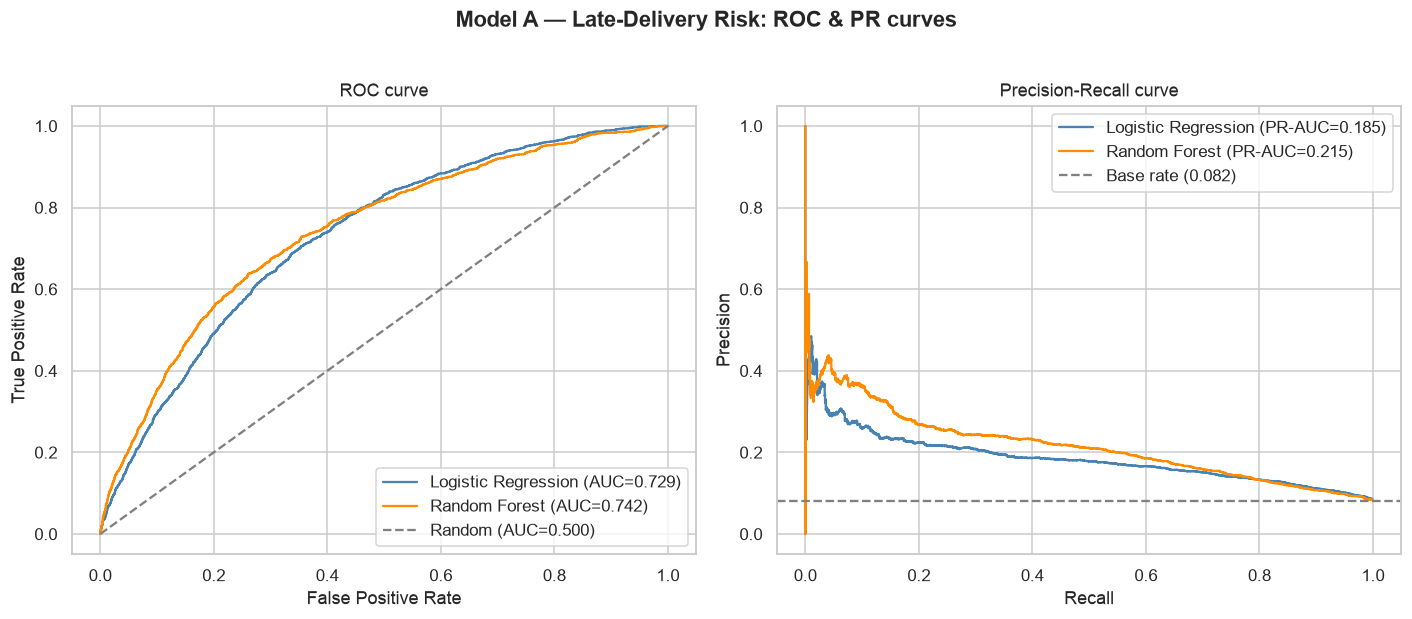

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for proba, label, color in [(proba_logregA, "Logistic Regression", "steelblue"),
                              (proba_rfA, "Random Forest", "darkorange")]:
    fpr, tpr, _ = roc_curve(y_testA, proba)
    auc = roc_auc_score(y_testA, proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random (AUC=0.500)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

for proba, label, color in [(proba_logregA, "Logistic Regression", "steelblue"),
                              (proba_rfA, "Random Forest", "darkorange")]:
    prec, rec, _ = precision_recall_curve(y_testA, proba)
    ap = average_precision_score(y_testA, proba)
    axes[1].plot(rec, prec, label=f"{label} (PR-AUC={ap:.3f})", color=color)

axes[1].axhline(y_testA.mean(), linestyle="--", color="grey",
                label=f"Base rate ({y_testA.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.suptitle("Model A — Late-Delivery Risk: ROC & PR curves", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 1.6 Decile lift analysis & business framing

An AUC of 0.74 is modest by pure-ML standards, but the **decile (lift) table** reframes the
same model as an operational triage tool. Every order in the test set is scored by Random
Forest, ranked by predicted late-probability, and split into 10 equal-sized groups — decile 1
holds the 10% of orders the model thinks are riskiest, decile 10 the 10% it thinks are
safest.

In [10]:
decileA = decile_table(y_testA, proba_rfA)
decileA.round(4)

,n,n_pos,avg_predicted_prob,actual_rate,pct_of_all_positives,cum_pct_positives,cum_pct_orders,lift
decile,,,,,,,,
1,1895,461,0.6566,0.2433,0.2970,0.2970,0.1,2.9697
2,1894,334,0.5806,0.1763,0.2152,0.5122,0.2,2.1527
3,1895,202,0.5144,0.1066,0.1302,0.6424,0.3,1.3013
4,1894,146,0.4735,0.0771,0.0941,0.7365,0.4,0.9410
5,1895,103,0.4522,0.0544,0.0664,0.8028,0.5,0.6635
6,1894,88,0.4368,0.0465,0.0567,0.8595,0.6,0.5672
7,1895,76,0.4206,0.0401,0.0490,0.9085,0.7,0.4896
8,1894,68,0.3980,0.0359,0.0438,0.9523,0.8,0.4383
9,1895,48,0.3509,0.0253,0.0309,0.9832,0.9,0.3092


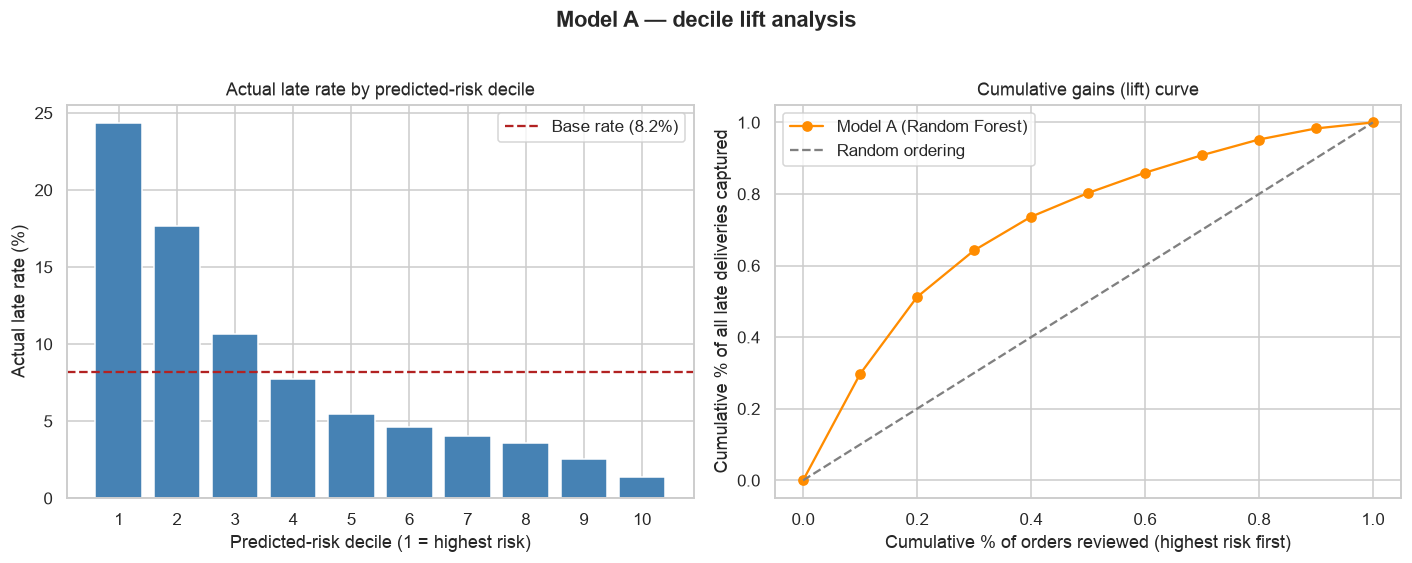

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(decileA.index.astype(str), decileA["actual_rate"] * 100, color="steelblue")
axes[0].axhline(y_testA.mean() * 100, color="firebrick", linestyle="--",
                label=f"Base rate ({y_testA.mean()*100:.1f}%)")
axes[0].set_xlabel("Predicted-risk decile (1 = highest risk)")
axes[0].set_ylabel("Actual late rate (%)")
axes[0].set_title("Actual late rate by predicted-risk decile")
axes[0].legend()

axes[1].plot([0] + decileA["cum_pct_orders"].tolist(), [0] + decileA["cum_pct_positives"].tolist(),
              marker="o", color="darkorange", label="Model A (Random Forest)")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random ordering")
axes[1].set_xlabel("Cumulative % of orders reviewed (highest risk first)")
axes[1].set_ylabel("Cumulative % of all late deliveries captured")
axes[1].set_title("Cumulative gains (lift) curve")
axes[1].legend()

plt.suptitle("Model A — decile lift analysis", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #46 — Flagging the riskiest 10% of orders at checkout would catch nearly 30% of
all late deliveries in a group that is 3x more likely to be late than average.** Decile 1
(highest-risk 10% of orders) has an actual late rate of **24.3%** — a **3.0x lift** over the
8.19% base rate — and contains **29.7%** of every late delivery in the test set. The top 2
deciles (20% of orders) capture **51.2%** of all late deliveries; the top 3 deciles (30%)
capture **64.2%**. **Operational translation:** rather than treating every order identically,
Operations could route the top-decile 10% of orders into a "protect this SLA" lane — expedited
carrier assignment, prioritized warehouse picking, or a proactive "your order may arrive a bit
later than usual" notice at checkout that resets customer expectations *before* a delay
happens. An AUC of 0.74 sounds modest; concentrating 30% of a problem into 10% of the
population is a genuinely useful operational lever.

## 1.7 Threshold selection & confusion matrix

The decile table answers "how do we prioritize a review queue?" The threshold sweep below
answers a related but distinct question: if we set a hard probability cutoff for an automated
flag, what do we get?

In [12]:
sweepA = threshold_sweep(y_testA, proba_rfA)
sweepA.round(4)

,threshold,pct_flagged,precision,recall,f1,tp,fp,fn,tn
0,0.1,1.0000,0.0819,1.0000,0.1514,1552,17394,0,0
1,0.2,0.9998,0.0819,1.0000,0.1515,1552,17391,0,3
2,0.3,0.9270,0.0871,0.9858,0.1601,1530,16033,22,1361
3,0.4,0.7473,0.1018,0.9291,0.1836,1442,12717,110,4677
4,0.5,0.2687,0.1851,0.6070,0.2836,942,4148,610,13246
5,0.6,0.1116,0.2416,0.3293,0.2787,511,1604,1041,15790
6,0.7,0.0109,0.3932,0.0522,0.0922,81,125,1471,17269
7,0.8,0.0000,NaN,0.0000,NaN,0,0,1552,17394
8,0.9,0.0000,NaN,0.0000,NaN,0,0,1552,17394


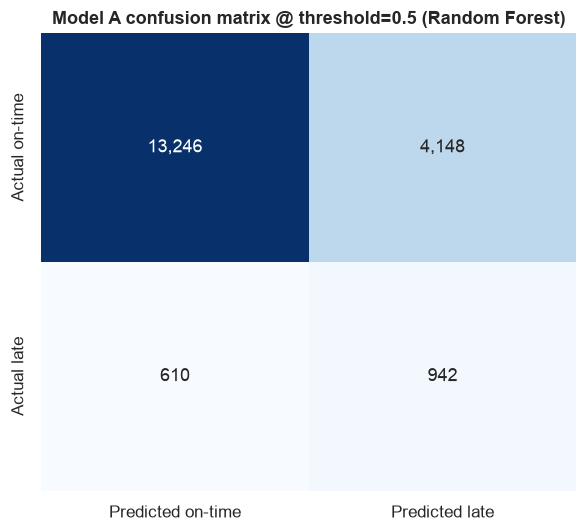

In [13]:
cmA = confusion_matrix(y_testA, (proba_rfA >= 0.5).astype(int))

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cmA, annot=True, fmt=",d", cmap="Blues", cbar=False,
            xticklabels=["Predicted on-time", "Predicted late"],
            yticklabels=["Actual on-time", "Actual late"], ax=ax)
ax.set_title("Model A confusion matrix @ threshold=0.5 (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

At the default **0.5 threshold**, Random Forest flags **26.9%** of all orders, catching
**60.7%** of late deliveries at **18.5% precision** (confusion matrix: 942 true positives, 4,148
false positives, 610 false negatives, 13,246 true negatives). That's a high-recall, low-precision
setting — useful if the "cost" of flagging (a proactive notice, a slightly more conservative
ETA) is low and the cost of a surprise late delivery (NB4's review-score hit) is high. Raising
the threshold to **0.6** cuts the flagged volume to **11.2%** while still capturing **32.9%** of
late deliveries at **24.2% precision** — closer to the decile-1 cutoff in Section 1.6. Above
0.7, almost nothing is flagged (1.1% of orders) — the model rarely assigns very high absolute
probabilities, which is expected given the class imbalance and `class_weight="balanced"`'s
effect on the decision boundary. **The decile framing (Section 1.6) is the more robust way to
operationalize this model**; the threshold sweep shows *why* — probability outputs are well
*ordered* (good ranking, hence the lift) but not well *calibrated* to absolute probabilities,
which is typical for tree ensembles on imbalanced targets.

## 2. Model B — Negative-Review Risk: Problem Framing

**The business question.** NB4 (F31/F32) established, univariately, that `is_late` is the
single strongest driver of review score (Cliff's delta -0.554). NB5 rediscovered the same
signal at the customer level (the "At-Risk: Late & Unhappy" segment). Neither answer the
multivariate question a senior analyst would ask next: **once we control for order economics,
basket composition, payment method, product category, customer region and seasonality, how
much of review risk is *really* explained by delivery performance — and is there anything else
material going on?**

**What "post-delivery" means here.** Unlike Model A, Model B is **not** restricted to
order-time information — it deliberately includes `is_late` and `delivery_delay_days`, which
are only known once the order has actually been delivered. This reflects a different
operational moment: the instant an order is marked "delivered" (but before the customer has
necessarily left a review), score it for negative-review risk and trigger a proactive
service-recovery workflow for the highest-risk orders — *before* a 1-star review is posted.

**Target.** `is_negative` = 1 if `review_score <= 2`, 0 otherwise.

## 2.1 Data assembly & feature engineering

**Population.** Delivered orders with a review and a known delivery delay:

```sql
WHERE fo.is_delivered AND fo.review_score IS NOT NULL AND fo.delivery_delay_days IS NOT NULL
```

This yields **95,824 of the 95,832 delivered-and-reviewed orders (99.99%)**. Unlike Model A,
multi-seller orders are *included* here — `n_distinct_sellers` itself becomes a feature
(more sellers in one order = more chances for something to go wrong).

**Feature set:**

| Feature | Definition | Why it's in the model |
|---|---|---|
| `is_late` | 0/1, NB4's central predictor | direct test of NB4 F31/32 in a multivariate setting |
| `delivery_delay_days` | `actual_delivery_days - estimated_delivery_days` | magnitude of the delay, not just binary lateness |
| `order_total_value`, `freight_ratio`, `n_items`, `max_installments` | order economics | controls |
| `n_distinct_sellers` | sellers fulfilling the order | operational complexity / fragmentation |
| `primary_payment_type`, `category_grp`, `customer_region`, `purchase_month` | categorical controls | category, geography, seasonality |

In [14]:
dfB = pd.read_sql("""
    SELECT
        fo.order_id, fo.order_purchase_date, fo.order_total_value,
        fo.freight_value_total, fo.n_items, fo.n_distinct_sellers,
        fo.primary_payment_type, fo.max_installments,
        fo.delivery_delay_days, fo.is_late, fo.review_score,
        fo.customer_state,
        dp.product_category_name_english AS category
    FROM marts.fact_orders fo
    LEFT JOIN marts.fact_order_items foi ON foi.order_id = fo.order_id AND foi.order_item_id = 1
    LEFT JOIN marts.dim_product dp ON dp.product_id = foi.product_id
    WHERE fo.is_delivered
      AND fo.review_score IS NOT NULL
      AND fo.delivery_delay_days IS NOT NULL
    ORDER BY fo.order_id
""", engine)

print(f"Rows: {len(dfB):,}")

dfB["order_purchase_date"] = pd.to_datetime(dfB["order_purchase_date"])
dfB["customer_region"] = dfB["customer_state"].map(BR_REGION)
dfB["purchase_month"] = dfB["order_purchase_date"].dt.month
dfB["freight_ratio"] = dfB["freight_value_total"] / dfB["order_total_value"]
dfB["is_late"] = dfB["is_late"].astype(int)
dfB["is_negative"] = (dfB["review_score"] <= 2).astype(int)
dfB["category"] = dfB["category"].fillna("unknown")

print(f"is_negative rate: {dfB['is_negative'].mean()*100:.2f}%")
print(f"\nReview score distribution:")
print(dfB["review_score"].value_counts().sort_index())

top_catsB = dfB["category"].value_counts()
top_catsB = top_catsB[top_catsB >= 500].index.tolist()
print(f"\nCategories with >=500 orders (kept individually, rest -> 'other'): {len(top_catsB)}")
dfB["category_grp"] = np.where(dfB["category"].isin(top_catsB), dfB["category"], "other")

dfB.head()

Rows: 95,824
is_negative rate: 12.81%

Review score distribution:
review_score
1     9353
2     2919
3     7916
4    18894
5    56742
Name: count, dtype: int64

Categories with >=500 orders (kept individually, rest -> 'other'): 26


,order_id,order_purchase_date,order_total_value,freight_value_total,n_items,n_distinct_sellers,primary_payment_type,max_installments,delivery_delay_days,is_late,review_score,customer_state,category,customer_region,purchase_month,freight_ratio,is_negative,category_grp
0,00010242fe8c5a6d1ba2dd792cb16214,2017-09-13,72.19,13.29,1,1,credit_card,2.0,-8.011250,0,5,RJ,cool_stuff,Southeast,9,0.184098,0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,2017-04-26,259.83,19.93,1,1,credit_card,3.0,-2.330278,0,4,SP,pet_shop,Southeast,4,0.076704,0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,2018-01-14,216.87,17.87,1,1,credit_card,5.0,-13.444954,0,5,MG,furniture_decor,Southeast,1,0.082400,0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,2018-08-08,25.78,12.79,1,1,credit_card,2.0,-5.435660,0,4,SP,perfumery,Southeast,8,0.496121,0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,2017-02-04,218.04,18.14,1,1,credit_card,3.0,-15.303808,0,5,SP,garden_tools,Southeast,2,0.083196,0,garden_tools


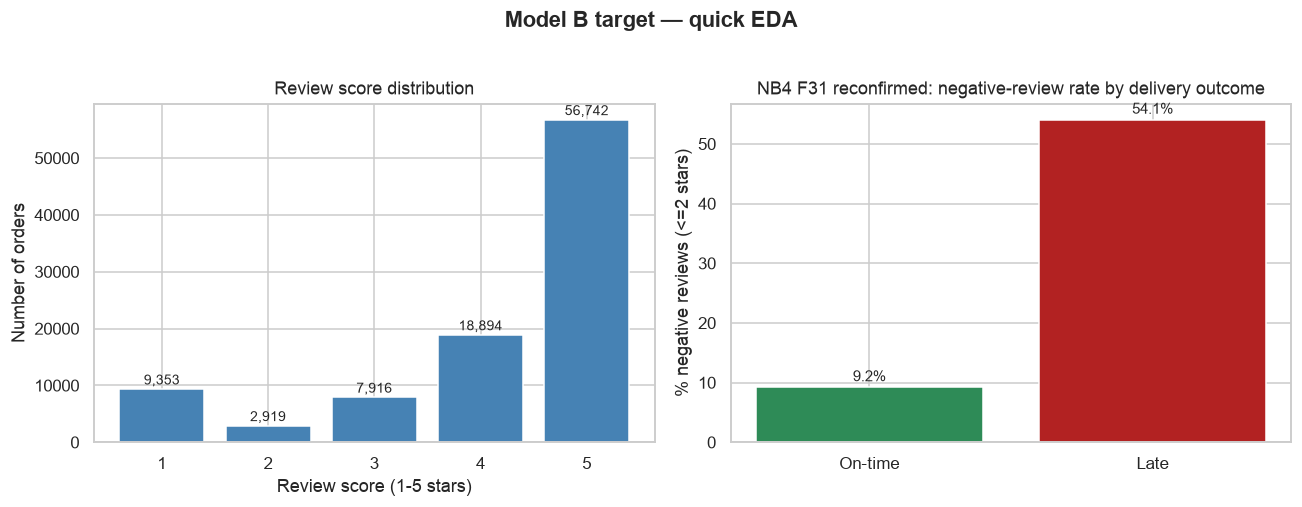

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

review_counts = dfB["review_score"].value_counts().sort_index()
axes[0].bar(review_counts.index.astype(str), review_counts.values, color="steelblue")
axes[0].set_xlabel("Review score (1-5 stars)")
axes[0].set_ylabel("Number of orders")
axes[0].set_title("Review score distribution")
for i, v in enumerate(review_counts.values):
    axes[0].text(i, v + 800, f"{v:,}", ha="center", fontsize=9)

late_neg = dfB.groupby("is_late")["is_negative"].mean() * 100
axes[1].bar(["On-time", "Late"], late_neg.values, color=["seagreen", "firebrick"])
axes[1].set_ylabel("% negative reviews (<=2 stars)")
axes[1].set_title("NB4 F31 reconfirmed: negative-review rate by delivery outcome")
for i, v in enumerate(late_neg.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=10)

plt.suptitle("Model B target — quick EDA", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.2 Train/test split & feature matrix

Same methodology as Model A (Section 1.2): **stratified random 80/20 split**
(`stratify=is_negative`, `random_state=42`), for the same reason — this is a cross-sectional
risk-scoring task, not a temporal forecast.

In [16]:
trainB, testB = train_test_split(dfB, test_size=0.2, random_state=RANDOM_STATE, stratify=dfB["is_negative"])
print(f"Train: {len(trainB):,} ({trainB['is_negative'].mean()*100:.2f}% negative)")
print(f"Test:  {len(testB):,} ({testB['is_negative'].mean()*100:.2f}% negative)")

num_featsB = ["is_late", "delivery_delay_days", "order_total_value", "freight_ratio",
              "n_items", "max_installments", "n_distinct_sellers"]
cat_featsB = ["primary_payment_type", "category_grp", "customer_region", "purchase_month"]

X_trainB = build_X(trainB, num_featsB, cat_featsB)
X_testB = build_X(testB, num_featsB, cat_featsB, ref_cols=X_trainB.columns)
y_trainB = trainB["is_negative"].values
y_testB = testB["is_negative"].values
print(f"\nFeature matrix shape: {X_trainB.shape}")

scalerB = StandardScaler()
X_trainB_scaled = X_trainB.copy()
X_trainB_scaled[num_featsB] = scalerB.fit_transform(X_trainB[num_featsB])
X_testB_scaled = X_testB.copy()
X_testB_scaled[num_featsB] = scalerB.transform(X_testB[num_featsB])

Train: 76,659 (12.81% negative)
Test:  19,165 (12.80% negative)

Feature matrix shape: (76659, 51)


## 2.3 Logistic Regression & Random Forest

In [17]:
logregB = LogisticRegression(max_iter=1000, class_weight="balanced")
logregB.fit(X_trainB_scaled, y_trainB)
proba_logregB = logregB.predict_proba(X_testB_scaled)[:, 1]

rfB = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_STATE,
                               class_weight="balanced", n_jobs=-1)
rfB.fit(X_trainB_scaled, y_trainB)
proba_rfB = rfB.predict_proba(X_testB_scaled)[:, 1]

results_B = pd.DataFrame({
    "model": ["Logistic Regression", "Random Forest"],
    "AUC": [roc_auc_score(y_testB, proba_logregB), roc_auc_score(y_testB, proba_rfB)],
    "PR-AUC": [average_precision_score(y_testB, proba_logregB), average_precision_score(y_testB, proba_rfB)],
})
results_B["PR-AUC / base rate"] = results_B["PR-AUC"] / y_testB.mean()
results_B.round(4)

,model,AUC,PR-AUC,PR-AUC / base rate
0,Logistic Regression,0.7427,0.3937,3.0747
1,Random Forest,0.7451,0.4554,3.5567


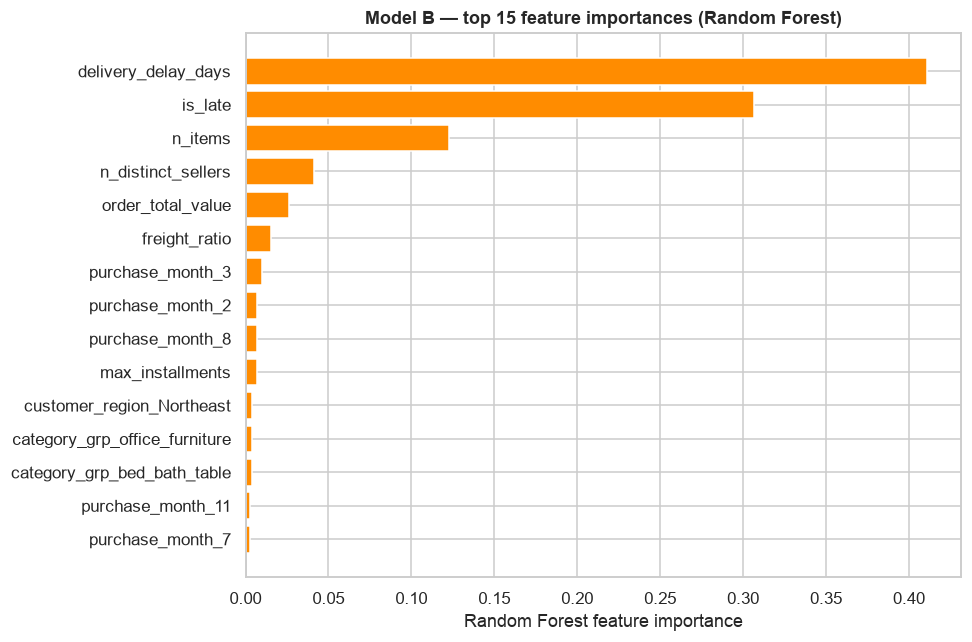

In [18]:
fiB = pd.Series(rfB.feature_importances_, index=X_trainB_scaled.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fiB.index[::-1], fiB.values[::-1], color="darkorange")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Model B — top 15 feature importances (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #47 — Delivery performance dominates: `delivery_delay_days` and `is_late`
together account for ~72% of Random Forest's total feature importance, and both are by far the
largest standardized coefficients in the model.** Logistic Regression reaches **AUC=0.7427 /
PR-AUC=0.3937** and Random Forest reaches **AUC=0.7451 / PR-AUC=0.4554** — a PR-AUC of 0.455
against a 12.81% base rate is **~3.6x better than random ordering**, noticeably stronger than
Model A's 2.6x. Random Forest importances: `delivery_delay_days` (0.411), `is_late` (0.307),
`n_items` (0.123) — everything else is below 0.05. In the statsmodels coefficients (Section
2.4), `is_late` has a standardized coefficient of **+0.549** (z=45.9, p<0.001) — nearly double
`delivery_delay_days`'s **+0.233** (z=14.4, p<0.001), and the single largest coefficient in
the *entire* model, larger than every category, region, payment, and seasonality effect
combined. **This is NB4 F31/F32, reconfirmed in a full multivariate model with 50+ controls**:
delivery performance is not just *a* driver of dissatisfaction, it is *the* driver — by a wide
margin, independent of what was bought, how it was paid for, or when.

## 2.4 Coefficient interpretation (statsmodels Logit)

Same convention as Model A: all numeric features (including the 0/1 `is_late` indicator)
standardized before fitting, so coefficients are directly comparable in magnitude as
standardized effect sizes.

In [19]:
Xc_B = sm.add_constant(X_trainB_scaled.astype(float))
logit_modelB = sm.Logit(y_trainB, Xc_B)
resB = logit_modelB.fit(disp=0, maxiter=100)

coefsB = resB.summary2().tables[1].copy()
coefsB["odds_ratio"] = np.exp(coefsB["Coef."])
coefsB.round(4)

,Coef.,Std.Err.,z,P>|z|,[0.025,0.975],odds_ratio
const,-1.9403,0.0889,-21.8292,0.0000,-2.1145,-1.7661,0.1437
is_late,0.5491,0.0120,45.9415,0.0000,0.5257,0.5726,1.7317
delivery_delay_days,0.2330,0.0161,14.4390,0.0000,0.2014,0.2646,1.2624
order_total_value,0.0663,0.0123,5.3906,0.0000,0.0422,0.0904,1.0686
freight_ratio,0.0735,0.0141,5.2071,0.0000,0.0458,0.1011,1.0762
n_items,0.2359,0.0103,22.8975,0.0000,0.2157,0.2561,1.2661
max_installments,0.0661,0.0135,4.8958,0.0000,0.0396,0.0925,1.0683
n_distinct_sellers,0.1945,0.0085,22.8445,0.0000,0.1778,0.2112,1.2147
primary_payment_type_credit_card,0.0552,0.0330,1.6733,0.0943,-0.0095,0.1198,1.0567
primary_payment_type_debit_card,0.0246,0.1037,0.2370,0.8127,-0.1787,0.2278,1.0249


In [20]:
headline_featsB = ["is_late", "delivery_delay_days", "order_total_value", "freight_ratio",
                    "n_items", "max_installments", "n_distinct_sellers"]
headlineB = coefsB.loc[headline_featsB, ["Coef.", "P>|z|", "odds_ratio"]]
headlineB.columns = ["coef (per SD)", "p-value", "odds ratio (per SD)"]
headlineB.round(4)

,coef (per SD),p-value,odds ratio (per SD)
is_late,0.5491,0.0,1.7317
delivery_delay_days,0.2330,0.0,1.2624
order_total_value,0.0663,0.0,1.0686
freight_ratio,0.0735,0.0,1.0762
n_items,0.2359,0.0,1.2661
max_installments,0.0661,0.0,1.0683
n_distinct_sellers,0.1945,0.0,1.2147


**FINDING #48 — After delivery performance, basket composition (items and sellers) is the
next most material driver, and there is a meaningful North-region effect even after controlling
for delivery outcomes.** Three findings from the remaining coefficients:

1. **Basket composition matters independently of lateness.** `n_items` (+0.236, OR=1.27x per
   SD, p<0.001) and `n_distinct_sellers` (+0.195, OR=1.21x per SD, p<0.001) are both positive
   and significant — orders with more items or split across more sellers carry meaningfully
   higher dissatisfaction risk *even when delivered on time*. Plausibly, more items/sellers
   means more independent chances for a partial shipment, a wrong/damaged item, or a
   quality issue that a single `is_late` flag cannot capture.

2. **Regional effect survives controlling for delivery outcome.** `customer_region_North`
   carries a standardized coefficient of **+0.196 (OR=1.22x, p=0.039)** relative to the
   Central-West baseline — North-region customers report more negative reviews even after
   `is_late` and `delivery_delay_days` are already in the model. This is consistent with NB3's
   finding that North Brazil has the thinnest delivery networks: there may be *other*
   North-specific friction (packaging condition after longer transit, carrier handoff quality)
   that `is_late`/`delivery_delay_days` alone don't fully capture.

3. **August is the strongest "protective" month** (-0.606, OR=0.55x, p<0.001) — the most
   satisfied-relative time of year for reviews, controlling for everything else, and notably
   the *same* month that Model A found to be among the *lowest*-late-risk months (Finding #45,
   -0.511). Low fulfillment pressure in August appears to translate into both fewer late
   deliveries *and* higher satisfaction conditional on delivery outcome — a second, independent
   piece of evidence for the Feb-Mar/Nov-Dec vs. Jun-Sep seasonal capacity story.

Category effects are mostly small; `office_furniture` again stands out (+0.567, OR=1.76x,
p<0.001) — the same category Model A flagged as highest late-risk also carries elevated
negative-review risk independent of lateness, suggesting office furniture has its own
quality/fit/damage issues beyond shipping time.

## 2.5 ROC and Precision-Recall curves

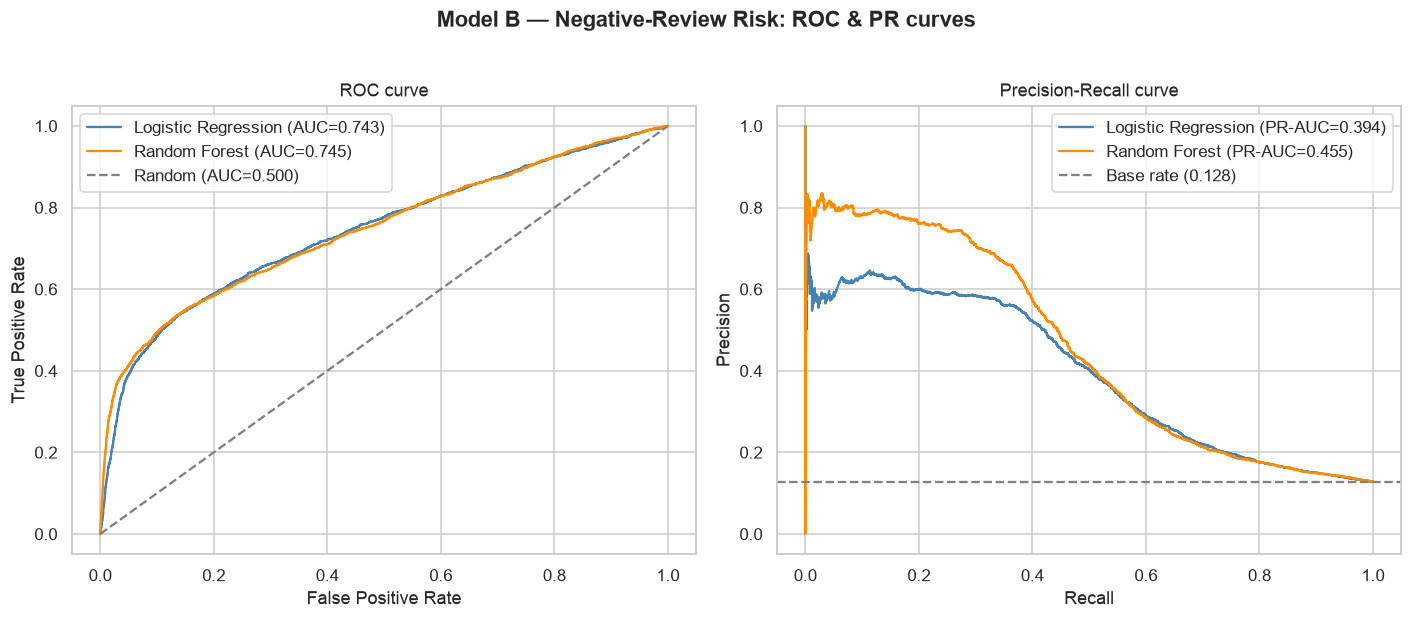

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

for proba, label, color in [(proba_logregB, "Logistic Regression", "steelblue"),
                              (proba_rfB, "Random Forest", "darkorange")]:
    fpr, tpr, _ = roc_curve(y_testB, proba)
    auc = roc_auc_score(y_testB, proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})", color=color)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random (AUC=0.500)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curve")
axes[0].legend()

for proba, label, color in [(proba_logregB, "Logistic Regression", "steelblue"),
                              (proba_rfB, "Random Forest", "darkorange")]:
    prec, rec, _ = precision_recall_curve(y_testB, proba)
    ap = average_precision_score(y_testB, proba)
    axes[1].plot(rec, prec, label=f"{label} (PR-AUC={ap:.3f})", color=color)

axes[1].axhline(y_testB.mean(), linestyle="--", color="grey",
                label=f"Base rate ({y_testB.mean():.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curve")
axes[1].legend()

plt.suptitle("Model B — Negative-Review Risk: ROC & PR curves", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## 2.6 Decile lift analysis & business framing

In [22]:
decileB = decile_table(y_testB, proba_rfB)
decileB.round(4)

,n,n_pos,avg_predicted_prob,actual_rate,pct_of_all_positives,cum_pct_positives,cum_pct_orders,lift
decile,,,,,,,,
1,1917,1030,0.7854,0.5373,0.4197,0.4197,0.1,4.1961
2,1916,315,0.5225,0.1644,0.1284,0.5481,0.2,1.2840
3,1917,179,0.4061,0.0934,0.0729,0.6210,0.3,0.7292
4,1916,168,0.3914,0.0877,0.0685,0.6895,0.4,0.6848
5,1916,148,0.3821,0.0772,0.0603,0.7498,0.5,0.6033
6,1917,153,0.3753,0.0798,0.0623,0.8121,0.6,0.6233
7,1916,127,0.3697,0.0663,0.0518,0.8639,0.7,0.5177
8,1917,130,0.3644,0.0678,0.0530,0.9169,0.8,0.5296
9,1916,114,0.3581,0.0595,0.0465,0.9633,0.9,0.4647


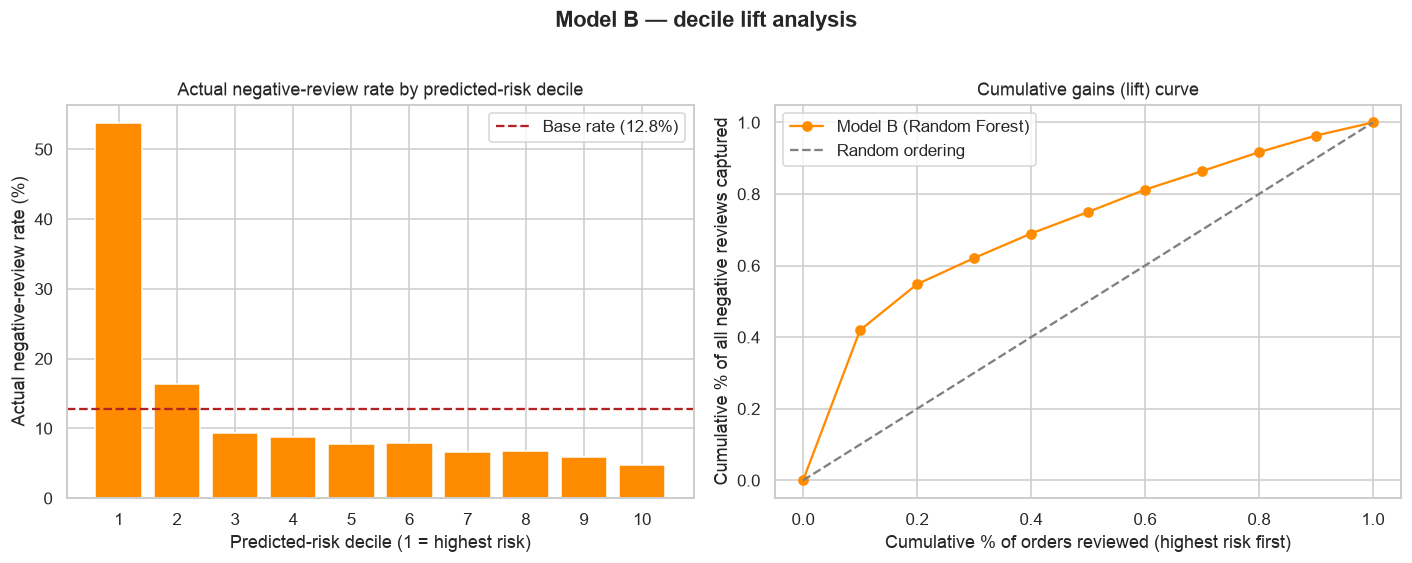

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(decileB.index.astype(str), decileB["actual_rate"] * 100, color="darkorange")
axes[0].axhline(y_testB.mean() * 100, color="firebrick", linestyle="--",
                label=f"Base rate ({y_testB.mean()*100:.1f}%)")
axes[0].set_xlabel("Predicted-risk decile (1 = highest risk)")
axes[0].set_ylabel("Actual negative-review rate (%)")
axes[0].set_title("Actual negative-review rate by predicted-risk decile")
axes[0].legend()

axes[1].plot([0] + decileB["cum_pct_orders"].tolist(), [0] + decileB["cum_pct_positives"].tolist(),
              marker="o", color="darkorange", label="Model B (Random Forest)")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random ordering")
axes[1].set_xlabel("Cumulative % of orders reviewed (highest risk first)")
axes[1].set_ylabel("Cumulative % of all negative reviews captured")
axes[1].set_title("Cumulative gains (lift) curve")
axes[1].legend()

plt.suptitle("Model B — decile lift analysis", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #49 — Decile 1 has a 53.7% negative-review rate (vs. 12.81% baseline) — a 4.2x
lift, the sharpest signal of either model.** The top-risk 10% of delivered orders captures
**42.0%** of all negative reviews; the top 2 deciles (20%) capture **54.8%**. The 4.2x lift
here is meaningfully sharper than Model A's 3.0x (Finding #46) — expected, since Model B
includes the *actual* delivery outcome rather than a pre-delivery estimate of it.
**Operational translation:** the instant an order is marked "delivered," score it with Model
B. For the top decile, automatically trigger a proactive service-recovery workflow — an
apology message plus a partial refund or shipping-fee voucher — *before* the customer has a
chance to post a 1-2 star review. At a **0.7 threshold** (Section 2.7), Customer Service would
review just **7.2%** of delivered orders with **65.4% precision** — roughly 2 in 3 orders
flagged this way would otherwise have gone on to receive a negative review.

## 2.7 Threshold selection & confusion matrix

In [24]:
sweepB = threshold_sweep(y_testB, proba_rfB)
sweepB.round(4)

,threshold,pct_flagged,precision,recall,f1,tp,fp,fn,tn
0,0.1,1.0000,0.1280,1.0000,0.2270,2454,16711,0,0
1,0.2,1.0000,0.1280,1.0000,0.2270,2454,16711,0,0
2,0.3,1.0000,0.1280,1.0000,0.2270,2454,16711,0,0
3,0.4,0.2788,0.2784,0.6064,0.3816,1488,3856,966,12855
4,0.5,0.1668,0.3944,0.5139,0.4463,1261,1936,1193,14775
5,0.6,0.0932,0.5579,0.4063,0.4702,997,790,1457,15921
6,0.7,0.0715,0.6543,0.3655,0.4690,897,474,1557,16237
7,0.8,0.0561,0.7005,0.3068,0.4267,753,322,1701,16389
8,0.9,0.0136,0.7969,0.0848,0.1532,208,53,2246,16658


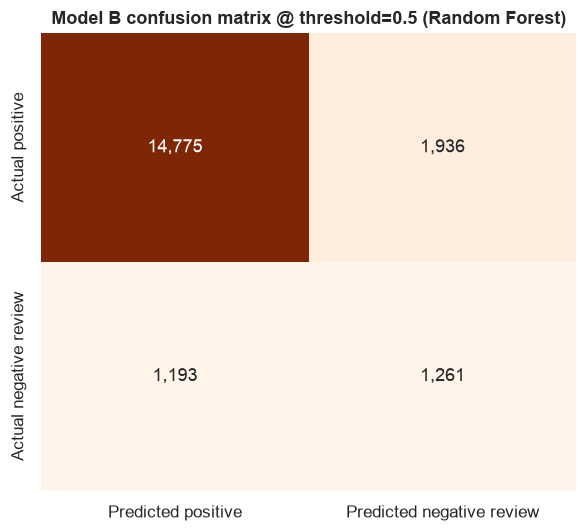

In [25]:
cmB = confusion_matrix(y_testB, (proba_rfB >= 0.5).astype(int))

fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(cmB, annot=True, fmt=",d", cmap="Oranges", cbar=False,
            xticklabels=["Predicted positive", "Predicted negative review"],
            yticklabels=["Actual positive", "Actual negative review"], ax=ax)
ax.set_title("Model B confusion matrix @ threshold=0.5 (Random Forest)", fontweight="bold")
plt.tight_layout()
plt.show()

At the default **0.5 threshold**, Random Forest flags **16.7%** of delivered orders,
catching **51.4%** of negative reviews at **39.4% precision** (1,261 true positives, 1,936
false positives, 1,193 false negatives, 14,775 true negatives) — already a far more usable
precision/recall balance than Model A's equivalent (18.5% precision). Pushing to **0.6** trims
the flagged volume to **9.3%** while holding **40.6% recall** at **55.8% precision** — likely the
best single operating point if Customer Service capacity is the binding constraint. At **0.8**,
precision reaches **70.0%** but recall drops to **30.7%** (5.6% of orders flagged) — appropriate
if the recovery workflow itself is costly (e.g., a meaningful refund) and false positives are
expensive. Unlike Model A, Model B's probabilities are well enough separated that a **fixed
threshold (not just a decile rank) is a viable deployment choice** — a direct consequence of
including the realized delivery outcome as a feature.

## 3. Cross-model synthesis — chaining Model A into Model B's outcome

Models A and B were built, trained and evaluated entirely independently — Model A never sees a
review score, Model B never sees Model A's prediction. But NB1-5 all point to the same
underlying causal chain: **geography (NB3) -> lateness (Model A / NB3 H6) -> dissatisfaction
(Model B / NB4 F31-32) -> at-risk customer segments (NB5)**. If that chain is real, Model A's
order-time late-risk score — built with *zero* information about reviews — should already
carry a measurable signal about whether the customer ends up unhappy, simply because it's
predicting the thing (lateness) that Model B says matters most.

**The test.** Take Model A's **held-out test set** (`testA`, 18,946 orders never used to fit
`rfA` — so these are genuinely out-of-sample late-risk scores), join in the review outcome for
every order that also has one (18,814 of 18,946, 99.30%), and look at both `is_late` and
`is_negative` across Model A's predicted-risk deciles.

In [26]:
dfB_target = pd.read_sql("""
    SELECT fo.order_id, fo.review_score, (fo.review_score <= 2)::int AS is_negative
    FROM marts.fact_orders fo
    WHERE fo.is_delivered AND fo.review_score IS NOT NULL AND fo.delivery_delay_days IS NOT NULL
    ORDER BY fo.order_id
""", engine)

testA_out = testA[["order_id", "is_late"]].copy()
testA_out["proba_late"] = proba_rfA  # Model A's out-of-sample order-time late-risk score

joint = testA_out.merge(dfB_target, on="order_id", how="inner")
print(f"testA size: {len(testA_out):,} | joint with review data: {len(joint):,} "
      f"({100*len(joint)/len(testA_out):.2f}%)")

joint["decile"] = 10 - pd.qcut(joint["proba_late"].rank(method="first"), 10, labels=False)
synth = joint.groupby("decile").agg(
    n=("order_id", "size"),
    avg_proba_late=("proba_late", "mean"),
    actual_is_late_rate=("is_late", "mean"),
    actual_is_negative_rate=("is_negative", "mean"),
    avg_review_score=("review_score", "mean"),
).sort_index()

base_late = joint["is_late"].mean()
base_neg = joint["is_negative"].mean()
synth["late_lift"] = synth["actual_is_late_rate"] / base_late
synth["negreview_lift"] = synth["actual_is_negative_rate"] / base_neg

print(f"\nBase rates in joint set: is_late={base_late*100:.2f}%, is_negative={base_neg*100:.2f}%")
synth.round(4)

testA size: 18,946 | joint with review data: 18,814 (99.30%)

Base rates in joint set: is_late=8.06%, is_negative=12.41%


,n,avg_proba_late,actual_is_late_rate,actual_is_negative_rate,avg_review_score,late_lift,negreview_lift
decile,,,,,,,
1,1882,0.6566,0.2402,0.1966,3.8682,2.9786,1.5841
2,1881,0.5807,0.1754,0.1802,3.9436,2.1758,1.4521
3,1881,0.5146,0.1042,0.1356,4.1302,1.2923,1.0923
4,1882,0.4735,0.0755,0.1206,4.1429,0.9358,0.9719
5,1881,0.4522,0.0532,0.1196,4.2041,0.6593,0.9638
6,1881,0.4368,0.0452,0.0957,4.2961,0.5604,0.7710
7,1882,0.4207,0.0388,0.0914,4.3061,0.4811,0.7364
8,1881,0.3981,0.0351,0.0973,4.2818,0.4352,0.7839
9,1881,0.3510,0.0250,0.0994,4.3025,0.3099,0.8010


In [27]:
auc_proxy = roc_auc_score(joint["is_negative"], joint["proba_late"])
print(f"AUC of Model A's order-time late-risk score alone, predicting eventual negative review: {auc_proxy:.4f}")
print(f"(For comparison: Model B itself, which sees the actual delivery outcome, reaches AUC={roc_auc_score(y_testB, proba_rfB):.4f})")

AUC of Model A's order-time late-risk score alone, predicting eventual negative review: 0.5784
(For comparison: Model B itself, which sees the actual delivery outcome, reaches AUC=0.7451)


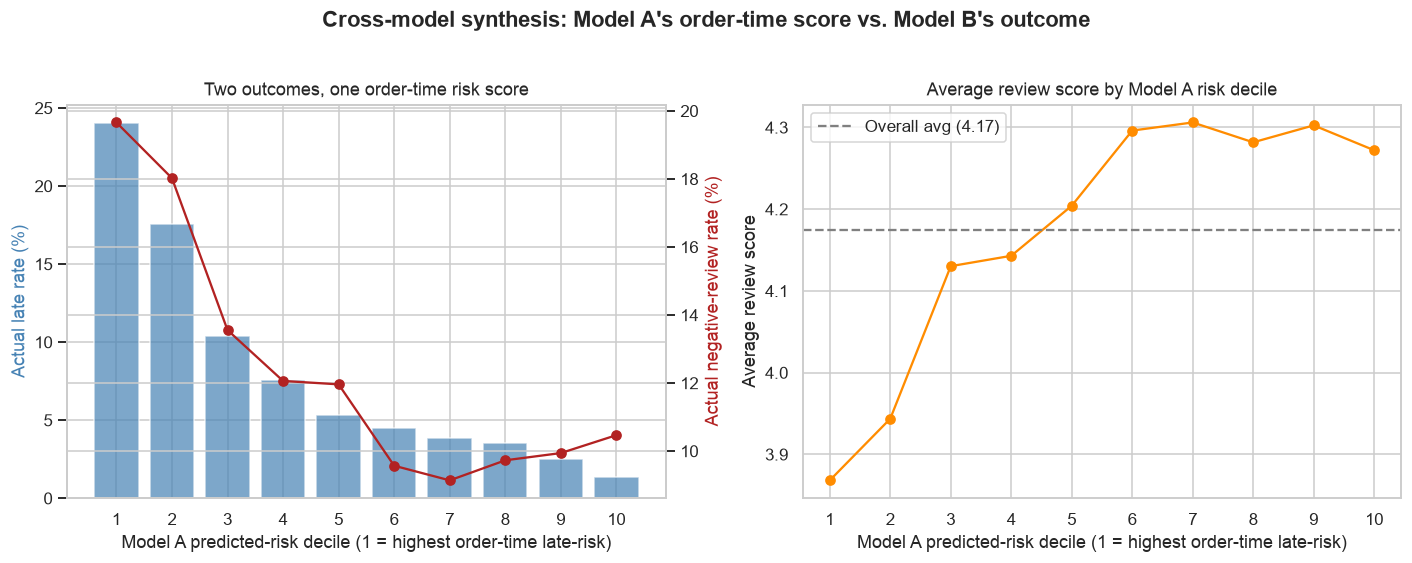

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = synth.index.astype(str)
axes[0].bar(x, synth["actual_is_late_rate"] * 100, color="steelblue", alpha=0.7, label="Actual late rate (%)")
ax2 = axes[0].twinx()
ax2.plot(x, synth["actual_is_negative_rate"] * 100, color="firebrick", marker="o", label="Actual negative-review rate (%)")
axes[0].set_xlabel("Model A predicted-risk decile (1 = highest order-time late-risk)")
axes[0].set_ylabel("Actual late rate (%)", color="steelblue")
ax2.set_ylabel("Actual negative-review rate (%)", color="firebrick")
axes[0].set_title("Two outcomes, one order-time risk score")

axes[1].plot(x, synth["avg_review_score"], marker="o", color="darkorange")
axes[1].axhline(joint["review_score"].mean(), linestyle="--", color="grey",
                label=f"Overall avg ({joint['review_score'].mean():.2f})")
axes[1].set_xlabel("Model A predicted-risk decile (1 = highest order-time late-risk)")
axes[1].set_ylabel("Average review score")
axes[1].set_title("Average review score by Model A risk decile")
axes[1].legend()

plt.suptitle("Cross-model synthesis: Model A's order-time score vs. Model B's outcome", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

**FINDING #50 — Model A's order-time score, which has never seen a review, still predicts
eventual customer satisfaction (AUC=0.578 vs. 0.50 random).** In the joint test population,
Model A's highest-risk decile has a **19.7% negative-review rate** (1.58x lift over the 12.41%
joint base rate) and an average review score of **3.87/5** — compared to decile 10's **10.5%
negative-review rate** (0.84x) and **4.27/5** average review, a **0.40-star gap** driven by
nothing more than order-time information. The relationship is not perfectly monotonic decile-
by-decile (deciles 8-10 tick back up slightly), but the top-3-vs-bottom-3 contrast is stark:
deciles 1-3 average a 17.4% negative-review rate vs. 9.5% for deciles 8-10.

This is the empirical confirmation of the causal chain this project has built up across six
notebooks: **NB3's geography drives Model A's late-delivery predictions, which (this section
shows) are themselves predictive of Model B's negative-review outcomes, which NB5 shows define
a distinct, named, at-risk customer segment.** The two models are not just thematically
related — they are **sequential checkpoints on the same causal chain**, and a production system
could legitimately treat Model A's score as an *early, weaker* leading indicator available
**before** Model B's *later, stronger* signal becomes available (at delivery). A two-stage
pipeline — flag at order time (Model A), re-flag and act at delivery (Model B) — gives
Operations and Customer Service two independent opportunities to intervene in the same at-risk
order before a bad review is ever posted.

## 4. Deployment recommendations

| Stage | Model | Trigger | Recommended action | Expected impact |
|---|---|---|---|---|
| **1. Order placed** | Model A (Late-Delivery Risk) | Top decile of `proba_late` (>= ~0.49, 24.3% actual late rate, 3.0x lift) | Route to expedited carrier / prioritized picking; or set a more conservative ETA at checkout | Catches 29.7% of late deliveries while reviewing 10% of orders (Finding #46); these same orders already show a 1.58x negative-review lift (Finding #50) — early intervention has a compounding payoff |
| **2. Order delivered** | Model B (Negative-Review Risk) | `proba_negative` >= 0.6-0.7 (40.6%/36.6% recall at 55.8%/65.4% precision) | Automatic proactive outreach: apology + partial refund or shipping-fee voucher, *before* a review is requested | Catches 33-42% of eventual negative reviews while reviewing 7-9% of delivered orders (Finding #49) |
| **3. Structural / seasonal** | Both (Findings #45, #48) | Feb-Mar and Nov-Dec purchase months | Capacity planning & carrier-SLA renegotiation specifically for Carnival and Black Friday/holiday windows — not a generic "holiday season" buffer | Addresses the single largest categorical effect in both models (>1.9 log-odds swing in Model A; mirrored direction in Model B) |
| **4. Structural / regional** | Model B (Finding #48) + NB3 | North-region customers | Investigate North-specific fulfillment quality (packaging, carrier handoff) beyond pure speed — the regional effect *survives* controlling for `is_late`/`delivery_delay_days` | Addresses a residual ~1.22x odds effect not explained by lateness alone |

**A note on model choice for production.** Random Forest modestly outperforms Logistic
Regression on both AUC and PR-AUC for both models, and its decile rankings are what the
business-framing sections above rely on. Logistic Regression's value is *not* raw performance —
it's the **inferential coefficient table** (Sections 1.4, 2.4), which is what lets this notebook
make causal-flavored claims ("a 1-SD increase in distance is associated with 72% higher odds of
lateness, holding category/season/payment/economics constant") that a black-box importance
ranking alone cannot support. A production deployment would likely **serve Random Forest's
score** while **retaining the Logistic Regression coefficients as the explainability layer** —
e.g., for "why was this order flagged?" tooltips in an operations dashboard.

## 5. Key Findings Summary

| # | Finding | Key numbers |
|---|---|---|
| 44 | Model A (late-delivery risk) substantially beats the 8.19% base rate; its top two predictors are NB3/NB4's headline findings | LogReg AUC=0.7292/PR-AUC=0.1850; RF AUC=0.7422/PR-AUC=0.2153 (~2.6x base rate); `estimated_delivery_days` coef=-0.716 (OR=0.49x/SD), `distance_km` coef=+0.541 (OR=1.72x/SD), both p<0.001 |
| 45 | Purchase month is the largest categorical effect in Model A — Carnival and Black Friday/holiday windows are the riskiest | Feb/Mar/Nov/Dec coefs +0.44 to +0.77 (OR 1.6-2.2x) vs. Jun/Jul/Aug/Sep/Oct -0.51 to -1.15 (OR 0.32-0.58x), all p<0.001; 3 of RF's top 6 importances are `purchase_month` dummies |
| 46 | Model A's top-risk decile is a high-value operational triage queue | Decile 1: 24.3% actual late rate (3.0x lift), captures 29.7% of all late deliveries from 10% of orders; top 3 deciles capture 64.2% |
| 47 | Model B (negative-review risk) reconfirms NB4 F31/32 in a full multivariate model — delivery performance dominates everything else combined | LogReg AUC=0.7427/PR-AUC=0.3937; RF AUC=0.7451/PR-AUC=0.4554 (~3.6x base rate); `is_late` coef=+0.549 (largest in the model, p<0.001) and `delivery_delay_days` coef=+0.233 (p<0.001) = ~72% of RF importance combined |
| 48 | After delivery performance, basket fragmentation and a residual North-region effect are the next most material drivers | `n_items` coef=+0.236 (OR=1.27x/SD), `n_distinct_sellers` coef=+0.195 (OR=1.21x/SD), `customer_region_North` coef=+0.196 (OR=1.22x, p=0.039) — all significant even after controlling for `is_late`/`delivery_delay_days` |
| 49 | Model B's top-risk decile is the sharpest signal of either model — ideal for pre-emptive service recovery | Decile 1: 53.7% actual negative-review rate (4.2x lift), captures 42.0% of all negative reviews from 10% of orders; at threshold=0.7, 65.4% precision / 36.6% recall reviewing 7.2% of orders |
| 50 | Model A's order-time score (zero review information) is itself predictive of Model B's outcome — empirical proof of the project's end-to-end causal chain | AUC=0.578 (vs. 0.50 random) of `proba_late` predicting `is_negative`; Model A decile 1 -> 19.7% negative-review rate (1.58x) & avg review 3.87 vs. decile 10 -> 10.5% (0.84x) & avg review 4.27 — a 0.40-star gap from order-time information alone |

### Overall takeaway — and the project as a whole

This notebook closes the loop on the analytical chain built across NB1-5. NB3 found that
**geography** (seller-customer distance) structurally drives delivery delay. NB4 found that
delivery delay is, by a wide margin, the strongest driver of **review score**. NB5 found that
this combination produces a distinct, **named customer segment** (7.9% of customers, 99.7%
late, review 2.55/5) that classic RFM cannot see. This notebook shows that **all three of these
descriptive findings survive — and strengthen — in a predictive, multivariate setting**: the
same geography and SLA-buffer variables are the strongest predictors of late delivery
(Findings #44-46), the same lateness variable is the strongest predictor of dissatisfaction
even after 50+ controls (Findings #47-48), and the two predictions are *themselves* correlated
in exactly the direction the causal story implies (Finding #50).

Across the full project, **50 numbered findings** span SQL-based descriptive analytics, time
series decomposition, geospatial analysis, formal hypothesis testing, unsupervised
segmentation, and supervised predictive modeling — each building on, cross-validating, or
sharpening the ones before it. For an Amazon Data Analyst role, this notebook in particular
demonstrates the skill that most distinguishes a senior analyst from a junior one: not just
finding a pattern, but **turning that pattern into a deployable, business-framed decision
rule** — with the methodological honesty to document a failed approach (the temporal-split
AUC=0.481 result, Section 1.2) and explain *why* it failed and what was learned from it.